# Preparation

In [1]:
# Data analysis and visualization package imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Import pengolahan file dan sistem
import os
import glob

In [2]:
# Data import from Github
!git clone https://github.com/thequerytrailblazer/wikimedia-id-retention-analysis.git

# Simpan path seluruh file CSV
path = './wikimedia-id-retention-analysis/data/source'
all_files = glob.glob(os.path.join(path, "*.csv"))

Cloning into 'wikimedia-id-retention-analysis'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 14 (delta 1), reused 14 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 13.66 KiB | 13.66 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [3]:
# Periksa shape() dari tiap csv files untuk memastikan tidak ada perbedaan jumlah kolom
for filename in all_files:
    df_temp = pd.read_csv(filename, sep=';')
    print(f"File: {os.path.basename(filename)} | Shape: {df_temp.shape}")

File: data_dan_teknologi_wikimedia_indonesia_2025-campaign_courses-2026-08-27.csv | Shape: (33, 24)
File: data_dan_teknologi_wikimedia_indonesia_2025-campaign_students-with_courses-2026-08-27.csv | Shape: (446, 3)
File: data_dan_teknologi_wikimedia_indonesia_2025-campaign_wikidata-2026-08-27.csv | Shape: (31, 28)


In [4]:
# Load dataframe
df_courses = pd.read_csv(os.path.join(path, 'data_dan_teknologi_wikimedia_indonesia_2025-campaign_courses-2026-08-27.csv'), sep=';')
df_students = pd.read_csv(os.path.join(path, 'data_dan_teknologi_wikimedia_indonesia_2025-campaign_students-with_courses-2026-08-27.csv'), sep=';')
df_wikidata = pd.read_csv(os.path.join(path, 'data_dan_teknologi_wikimedia_indonesia_2025-campaign_wikidata-2026-08-27.csv'), sep=';')

In [5]:
df_courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   course_slug                          33 non-null     object 
 1   title                                33 non-null     object 
 2   institution                          33 non-null     object 
 3   term                                 2 non-null      object 
 4   home_wiki                            33 non-null     object 
 5   created_at                           33 non-null     object 
 6   start_date                           33 non-null     object 
 7   end_date                             33 non-null     object 
 8   new_or_returning                     33 non-null     object 
 9   editors                              33 non-null     int64  
 10  new_editors                          33 non-null     int64  
 11  articles_edited                   

In [6]:
df_courses.head()

,course_slug,title,institution,term,home_wiki,created_at,start_date,end_date,new_or_returning,editors,...,references_added,total_edits,mainspace_edits,article_talk_edits,userspace_edits,article_views,upload_count,uploads_used_in_articles,upload_usage_count_across_all_wikis,training_completion_rate
0,Wikimedia_Indonesia/Geodatathon_Agustus_2025,Geodatathon Agustus 2025,Wikimedia Indonesia,NaN,www.wikidata.org,2025-08-22 14:46:47 UTC,2025-08-26 17:00:00 UTC,2025-08-29 16:59:00 UTC,returning_instructor,26,...,54944,324843,4921.0,NaN,NaN,10746,6,3,4,1.0
1,Wikimedia_Indonesia/Kopdar_Wikidata_Padang_15_...,Kopdar Wikidata Padang 15 November 2025,Wikimedia Indonesia,NaN,www.wikidata.org,2025-11-10 03:41:49 UTC,2025-11-14 23:00:00 UTC,2025-11-15 23:00:00 UTC,returning_instructor,7,...,0,650,650.0,NaN,NaN,1867,0,0,0,1.0
2,Wikimedia_Indonesia/Wikilatih_Wikidata_UISU_27...,Wikilatih Wikidata UISU 27 Oktober 2025,Wikimedia Indonesia,NaN,www.wikidata.org,2025-11-12 04:46:28 UTC,2025-10-26 23:00:00 UTC,2025-10-27 23:00:00 UTC,returning_instructor,18,...,0,150,NaN,NaN,NaN,640,0,0,0,1.0
3,Wikimedia_Indonesia/Kopdar_Wikimedia_Surabaya_...,Kopdar Wikimedia Surabaya 20 November 2025,Wikimedia Indonesia,20-Nov-25,www.wikidata.org,2025-11-14 12:21:04 UTC,2025-11-19 22:00:00 UTC,2025-11-20 22:00:00 UTC,returning_instructor,10,...,20,85,85.0,NaN,NaN,8508,0,0,0,1.0
4,Wikimedia_Indonesia/Wikilatih_Wikidata_UNAIR_2...,Wikilatih Wikidata UNAIR 21 November 2025,Wikimedia Indonesia,NaN,www.wikidata.org,2025-11-14 12:26:09 UTC,2025-11-20 22:00:00 UTC,2025-11-21 22:00:00 UTC,returning_instructor,16,...,4,122,91.0,NaN,31.0,236,0,0,0,1.0


In [7]:
df_students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   username       446 non-null    object
 1   course         446 non-null    object
 2   registered_at  443 non-null    object
dtypes: object(3)
memory usage: 10.6+ KB


In [8]:
df_students.head()

,username,course,registered_at
0,Adhmi,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2018-05-03 07:41:24 UTC
1,Rinai Natsumi,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2017-11-04 05:27:20 UTC
2,Sygrayem,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2014-12-17 13:11:20 UTC
3,JumadilM,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2019-12-15 13:25:14 UTC
4,Supardisahabu,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2019-12-28 11:48:42 UTC


In [9]:
df_wikidata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   course name              31 non-null     object
 1   claims created           31 non-null     int64 
 2   claims changed           31 non-null     int64 
 3   claims removed           31 non-null     int64 
 4   items created            31 non-null     int64 
 5   lexeme items created     31 non-null     int64 
 6   labels added             31 non-null     int64 
 7   labels changed           31 non-null     int64 
 8   labels removed           31 non-null     int64 
 9   descriptions added       31 non-null     int64 
 10  descriptions changed     31 non-null     int64 
 11  descriptions removed     31 non-null     int64 
 12  aliases added            31 non-null     int64 
 13  aliases changed          31 non-null     int64 
 14  aliases removed          31 non-null     int

In [10]:
df_wikidata.head()# 2. Data Cleaning Teks / Whitespace
df_students['username'] = df_students['username'].str.strip()
df_students['course'] = df_students['course'].str.strip()
df_courses['course_slug'] = df_courses['course_slug'].str.strip()

# Data cleaning & merging

In [11]:
# Whitespace removal
df_students['username'] = df_students['username'].str.strip()
df_students['course'] = df_students['course'].str.strip()
df_courses['course_slug'] = df_courses['course_slug'].str.strip()

In [12]:
# Merging student and course to show username's courses mapping
df_merged = pd.merge(
    df_students,
    df_courses[['course_slug', 'start_date']],
    left_on='course',
    right_on='course_slug',
    how='left'
).drop(columns=['course_slug'])

In [13]:
# Table info
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   username       446 non-null    object
 1   course         446 non-null    object
 2   registered_at  443 non-null    object
 3   start_date     446 non-null    object
dtypes: object(4)
memory usage: 14.1+ KB


In [14]:
# Check for null values
df_merged.isnull().sum()

,0
username,0
course,0
registered_at,3
start_date,0


In [15]:
# Drop null values based on 'registered_at'
df_merged = df_merged.dropna(subset=['registered_at']).reset_index(drop=True)

In [16]:
# Table info
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   username       443 non-null    object
 1   course         443 non-null    object
 2   registered_at  443 non-null    object
 3   start_date     443 non-null    object
dtypes: object(4)
memory usage: 14.0+ KB


In [17]:
# First five rows
df_merged.head()

,username,course,registered_at,start_date
0,Adhmi,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2018-05-03 07:41:24 UTC,2025-08-26 17:00:00 UTC
1,Rinai Natsumi,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2017-11-04 05:27:20 UTC,2025-08-26 17:00:00 UTC
2,Sygrayem,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2014-12-17 13:11:20 UTC,2025-08-26 17:00:00 UTC
3,JumadilM,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2019-12-15 13:25:14 UTC,2025-08-26 17:00:00 UTC
4,Supardisahabu,Wikimedia_Indonesia/Geodatathon_Agustus_2025,2019-12-28 11:48:42 UTC,2025-08-26 17:00:00 UTC


In [18]:
# Datetime conversion for datetime columns
df_merged['registered_at'] = pd.to_datetime(df_merged['registered_at'])
df_merged['start_date'] = pd.to_datetime(df_merged['start_date'])

In [19]:
# Check dtypes
print(df_merged.dtypes)

username                      object
course                        object
registered_at    datetime64[ns, UTC]
start_date       datetime64[ns, UTC]
dtype: object


In [20]:
# Check min and max of registered at of accounts and event start date
print(f"Min registered at: {df_merged['registered_at'].min()}")
print(f"Max registered at: {df_merged['registered_at'].max()}")
print(f"Min start date: {df_merged['start_date'].min()}")
print(f"Max start date: {df_merged['start_date'].max()}")

Min registered at: 2008-05-31 15:13:33+00:00
Max registered at: 2026-06-21 03:32:54+00:00
Min start date: 2025-08-26 17:00:00+00:00
Max start date: 2026-06-20 23:00:00+00:00


In [21]:
# Check for register date AFTER event start date
anomalies = df_merged[df_merged['registered_at'] > df_merged['start_date']]
print(f"Rows of usernames created after event start date: {len(anomalies)}")

Rows of usernames created after event start date: 86


In [22]:
# Total of records
total_records = len(df_merged)
print(f"Total records: {total_records}")

Total records: 443


In [23]:
# Count unique username
unique_users_exact = df_merged['username'].nunique()
print(f"Total unique users: {unique_users_exact}")

Total unique users: 369


In [24]:
# Count unique usernames lowercased
unique_users_lowercased = df_merged['username'].str.lower().nunique()
print(f"Total unique users lowercased: {unique_users_lowercased}")

Total unique users lowercased: 369


# Feature engineering

In [25]:
# Counting account age based on registered and start event date
df_merged['account_age_days'] = (df_merged['start_date'] - df_merged['registered_at']).dt.total_seconds() / (24 * 3600)

In [26]:
# Classifying accounts based on their age
df_merged['user_cohort'] = np.where(df_merged['account_age_days'] <= 7, 'New User', 'Existing User')

In [27]:
# Validation of new column
print("--- Users Cohort Distribution ---")
print(df_merged['user_cohort'].value_counts())
print("\n--- Statistical review of user account ages ---")
print(df_merged.groupby('user_cohort')['account_age_days'].describe())

--- Users Cohort Distribution ---
user_cohort
Existing User    274
New User         169
Name: count, dtype: int64

--- Statistical review of user account ages ---
               count         mean          std       min         25%  \
user_cohort                                                            
Existing User  274.0  1087.090354  1270.888358  7.313681  205.438455   
New User       169.0     0.674715     1.442068 -1.455764   -0.207431   

                      50%          75%          max  
user_cohort                                          
Existing User  638.756985  1505.581403  6479.895289  
New User        -0.006389     0.844965     6.307326  


In [28]:
# Cast df_merged into csv
df_merged.to_csv('retention_cleaned.csv', index=False)

# Exploratory Data Analysis

In [29]:
# Counting activities each username participated
user_activity = df_merged.groupby('username').agg(
    total_events=('course', 'count'),
    cohort=('user_cohort', 'first') # First time participating
).reset_index()

In [30]:
# Grouping of participation levels
user_activity['participation_type'] = np.where(
    user_activity['total_events'] > 1,
    'Repeat Participant (>1 Event)',
    'Single Event Participant (1 Event)'
)

In [31]:
print("--- Summary of Participants Participation Levels ---")
print(user_activity['participation_type'].value_counts())

--- Summary of Participants Participation Levels ---
participation_type
Single Event Participant (1 Event)    316
Repeat Participant (>1 Event)          53
Name: count, dtype: int64


In [32]:
print("\n--- Retention Distribution ---")
print(pd.crosstab(user_activity['cohort'], user_activity['participation_type'], margins=True))


--- Retention Distribution ---
participation_type  Repeat Participant (>1 Event)  \
cohort                                              
Existing User                                  47   
New User                                        6   
All                                            53   

participation_type  Single Event Participant (1 Event)  All  
cohort                                                       
Existing User                                      157  204  
New User                                           159  165  
All                                                316  369  


# Data Visualization

In [33]:
# Set graph style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Previous crosstab data
categories = ['Existing User', 'New User']
single_event = [157, 159]
repeat_event = [47, 6]

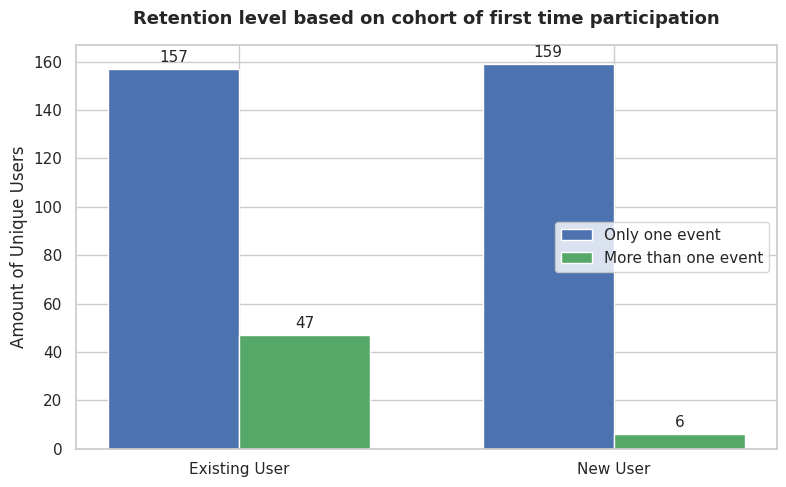

<Figure size 640x480 with 0 Axes>

In [34]:
# Bar Chart comparison between cohorts
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.35
x = np.arange(len(categories))

bars1 = ax.bar(x - bar_width/2, single_event, bar_width, label='Only one event', color='#4C72B0')
bars2 = ax.bar(x + bar_width/2, repeat_event, bar_width, label='More than one event', color='#55A868')

ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)

ax.set_ylabel('Amount of Unique Users')
ax.set_title('Retention level based on cohort of first time participation', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.show()
plt.savefig("retention_by_cohort_mpl.png", dpi=300, bbox_inches='tight')

In [35]:
# Retention level per cohort group using Plotly

# Aggregating data from df_merged
df_bar = df_merged.groupby(['user_cohort', 'username'])['course'].count().reset_index()
df_bar['participation_type'] = np.where(df_bar['course'] > 1, 'More than 1 event', 'Only 1 event')
df_bar_summary = df_bar.groupby(['user_cohort', 'participation_type']).size().reset_index(name='count')

fig_bar = px.bar(
    df_bar_summary,
    x='user_cohort',
    y='count',
    color='participation_type',
    barmode='group',
    text='count',
    title='Retention Level Based on Cohort of First Time Participation',
    labels={
        'user_cohort': 'User Cohort',
        'count': 'Amount of Unique Users',
        'participation_type': 'Participation Type'
    },
    color_discrete_map={
        'Only 1 event': '#4C72B0',
        'More than 1 event': '#55A868'
    }
)

fig_bar.update_traces(textposition='outside')
fig_bar.update_layout(
    template='plotly_white',
    hovermode='x unified',
    yaxis=dict(range=[0, max(df_bar_summary['count']) * 1.15])
)

fig_bar.show()

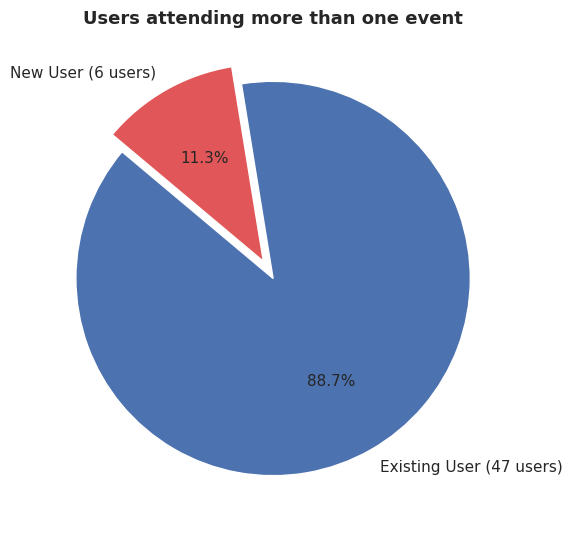

<Figure size 640x480 with 0 Axes>

In [36]:
# Pie chart of returning user profiles
fig, ax = plt.subplots(figsize=(6, 6))

labels = ['Existing User (47 users)', 'New User (6 users)']
sizes = [47, 6]
colors = ['#4C72B0', '#E15759']

ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0, 0.1))
ax.set_title('Users attending more than one event', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig("repeat_participant_composition_mpl.png", dpi=300, bbox_inches='tight')

In [37]:
# Plotly Repeat Participants Composition
df_repeat = df_bar[df_bar['participation_type'] == 'More than 1 event']
df_pie_summary = df_repeat['user_cohort'].value_counts().reset_index()
df_pie_summary.columns = ['user_cohort', 'count']

fig_pie = px.pie(
    df_pie_summary,
    values='count',
    names='user_cohort',
    title='Users Attending More Than One Event (Repeat Participants)',
    hole=0.4,
    color='user_cohort',
    color_discrete_map={
        'Existing User': '#4C72B0',
        'New User': '#E15759'
    }
)

fig_pie.update_traces(
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>Total Users: %{value}<br>Percentage: %{percent}'
)

fig_pie.update_layout(template='plotly_white')
fig_pie.show()

In [38]:
# Sel 3: Plotly Line Chart - Time Series Participation Trend
# Agregasi jumlah peserta berdasarkan start_date dan user_cohort
df_timeseries = df_merged.groupby(['start_date', 'user_cohort']).size().reset_index(name='participant_count')

fig_line = px.line(
    df_timeseries,
    x='start_date',
    y='participant_count',
    color='user_cohort',
    markers=True,
    title='Participation Trend Over Time (New Users vs Existing Users)',
    labels={
        'start_date': 'Event Date',
        'participant_count': 'Number of Participants',
        'user_cohort': 'User Cohort'
    },
    color_discrete_map={
        'Existing User': '#4C72B0',
        'New User': '#E15759'
    }
)

fig_line.update_traces(line=dict(width=2.5), marker=dict(size=7))
fig_line.update_layout(
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(title='Event Start Date', showgrid=True),
    yaxis=dict(title='Participant Count', showgrid=True)
)

fig_line.show()

In [39]:
# Save Plotly figures (HTML)
fig_bar.write_html("retention_by_cohort.html")
fig_pie.write_html("repeat_participant_composition.html")
fig_line.write_html("time_series_trend.html")

# Summary of Findings and Recommendations

### Key Takeaways
* Out of 165 new users, only 3.6% (6 users) returned for subsequent events, highlighting a significant drop-off immediately after initial onboarding sessions.
* The vast majority of retained participants (88.7% or 47 users) were existing account holders prior to the events, showing that long-term participation relies heavily on pre-established contributors.
* The 'New User' category strictly measures account creation recency (<= 7 days from event start date). Once a user attends a subsequent event, they are categorized under 'Existing User' regardless of their overall experience level. While functionally effective for tracking initial account creation during events, qualitative onboarding typically spans several months.

---

### Nuanced Context: The Nature of Volunteering and Wikidata's Learning Curve
* Contributing to Wikimedia projects is essentially a voluntary hobby. Encouraging individuals to regularly dedicate personal time to open data and open knowledge is an inherently complex retention challenge.
* Unlike Wikipedia or Wikimedia Commons where contributions yield immediate visual results, Wikidata operates as a graph-based knowledge base. Because its data is primarily consumed programmatically through SPARQL, SQL, linked data, or Web 3.0, non-technical beginners often struggle to see the tangible impact of their edits right away.

---

### Strategic Recommendations for Wikimedia Indonesia
* Shift outreach targets toward academics, data practitioners, and domain experts in fields such as GLAM, botany, or zoology. Focusing on niche, thematic data integration aligns Wikidata's complexity with audiences who already possess relevant data skills and domain interests.
* Recognize the trade-offs of this targeted approach. While user retention numbers may remain modest due to the niche nature of the work, success can instead be measured by data utility, evaluating how contributed data is actively queried, visualized, and integrated into external applications or research.
* For general beginner events, bridge the immediate feedback gap by integrating simple query visualizations or practical application demos into training sessions, helping new users directly visualize the real-world utility of their contributions.